# ENTRENAMIENTO SEGMENTADOR_HEPÁTICO-AI

In [ ]:
!nvidia-smi

Sun Apr  6 14:44:39 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8             10W /   70W |       2MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import os
HOME = os.getcwd()
print(HOME)

/content


In [ ]:
!pip install ultralytics==8.2.103 -q

from IPython import display
display.clear_output()

import ultralytics
ultralytics.checks()

Ultralytics YOLOv8.0.196 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 41.4/112.6 GB disk)


In [ ]:
from ultralytics import YOLO

from IPython.display import display, Image

In [ ]:
!mkdir -p {HOME}/datasets
%cd {HOME}/datasets

!pip install roboflow==1.1.48 --quiet

from roboflow import Roboflow

rf = Roboflow(api_key="IuPhPHcxGzj4B0FiPQFS")

project = rf.workspace("hccai").project("liver_ultrasound-phwos")
version = project.version(3)
dataset = version.download("yolov8")



/content/datasets
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 2.3 MB/s eta 0:00:00
loading Roboflow workspace...
loading Roboflow project...


## Custom Training

In [ ]:
from roboflow import Roboflow

%cd {HOME}

!yolo task=detect mode=train model=yolov8s.pt data={dataset.location}/data.yaml epochs=200 imgsz=800 patience=10


/content
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
New https://pypi.org/project/ultralytics/8.3.102 available 😃 Update with 'pip install -U ultralytics'
Ultralytics YOLOv8.2.103 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolov8s.pt, data=/content/datasets/liver_ultrasound-3/data.yaml, epochs=200, time=None, patience=10, batch=16, imgsz=800, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=F

/content


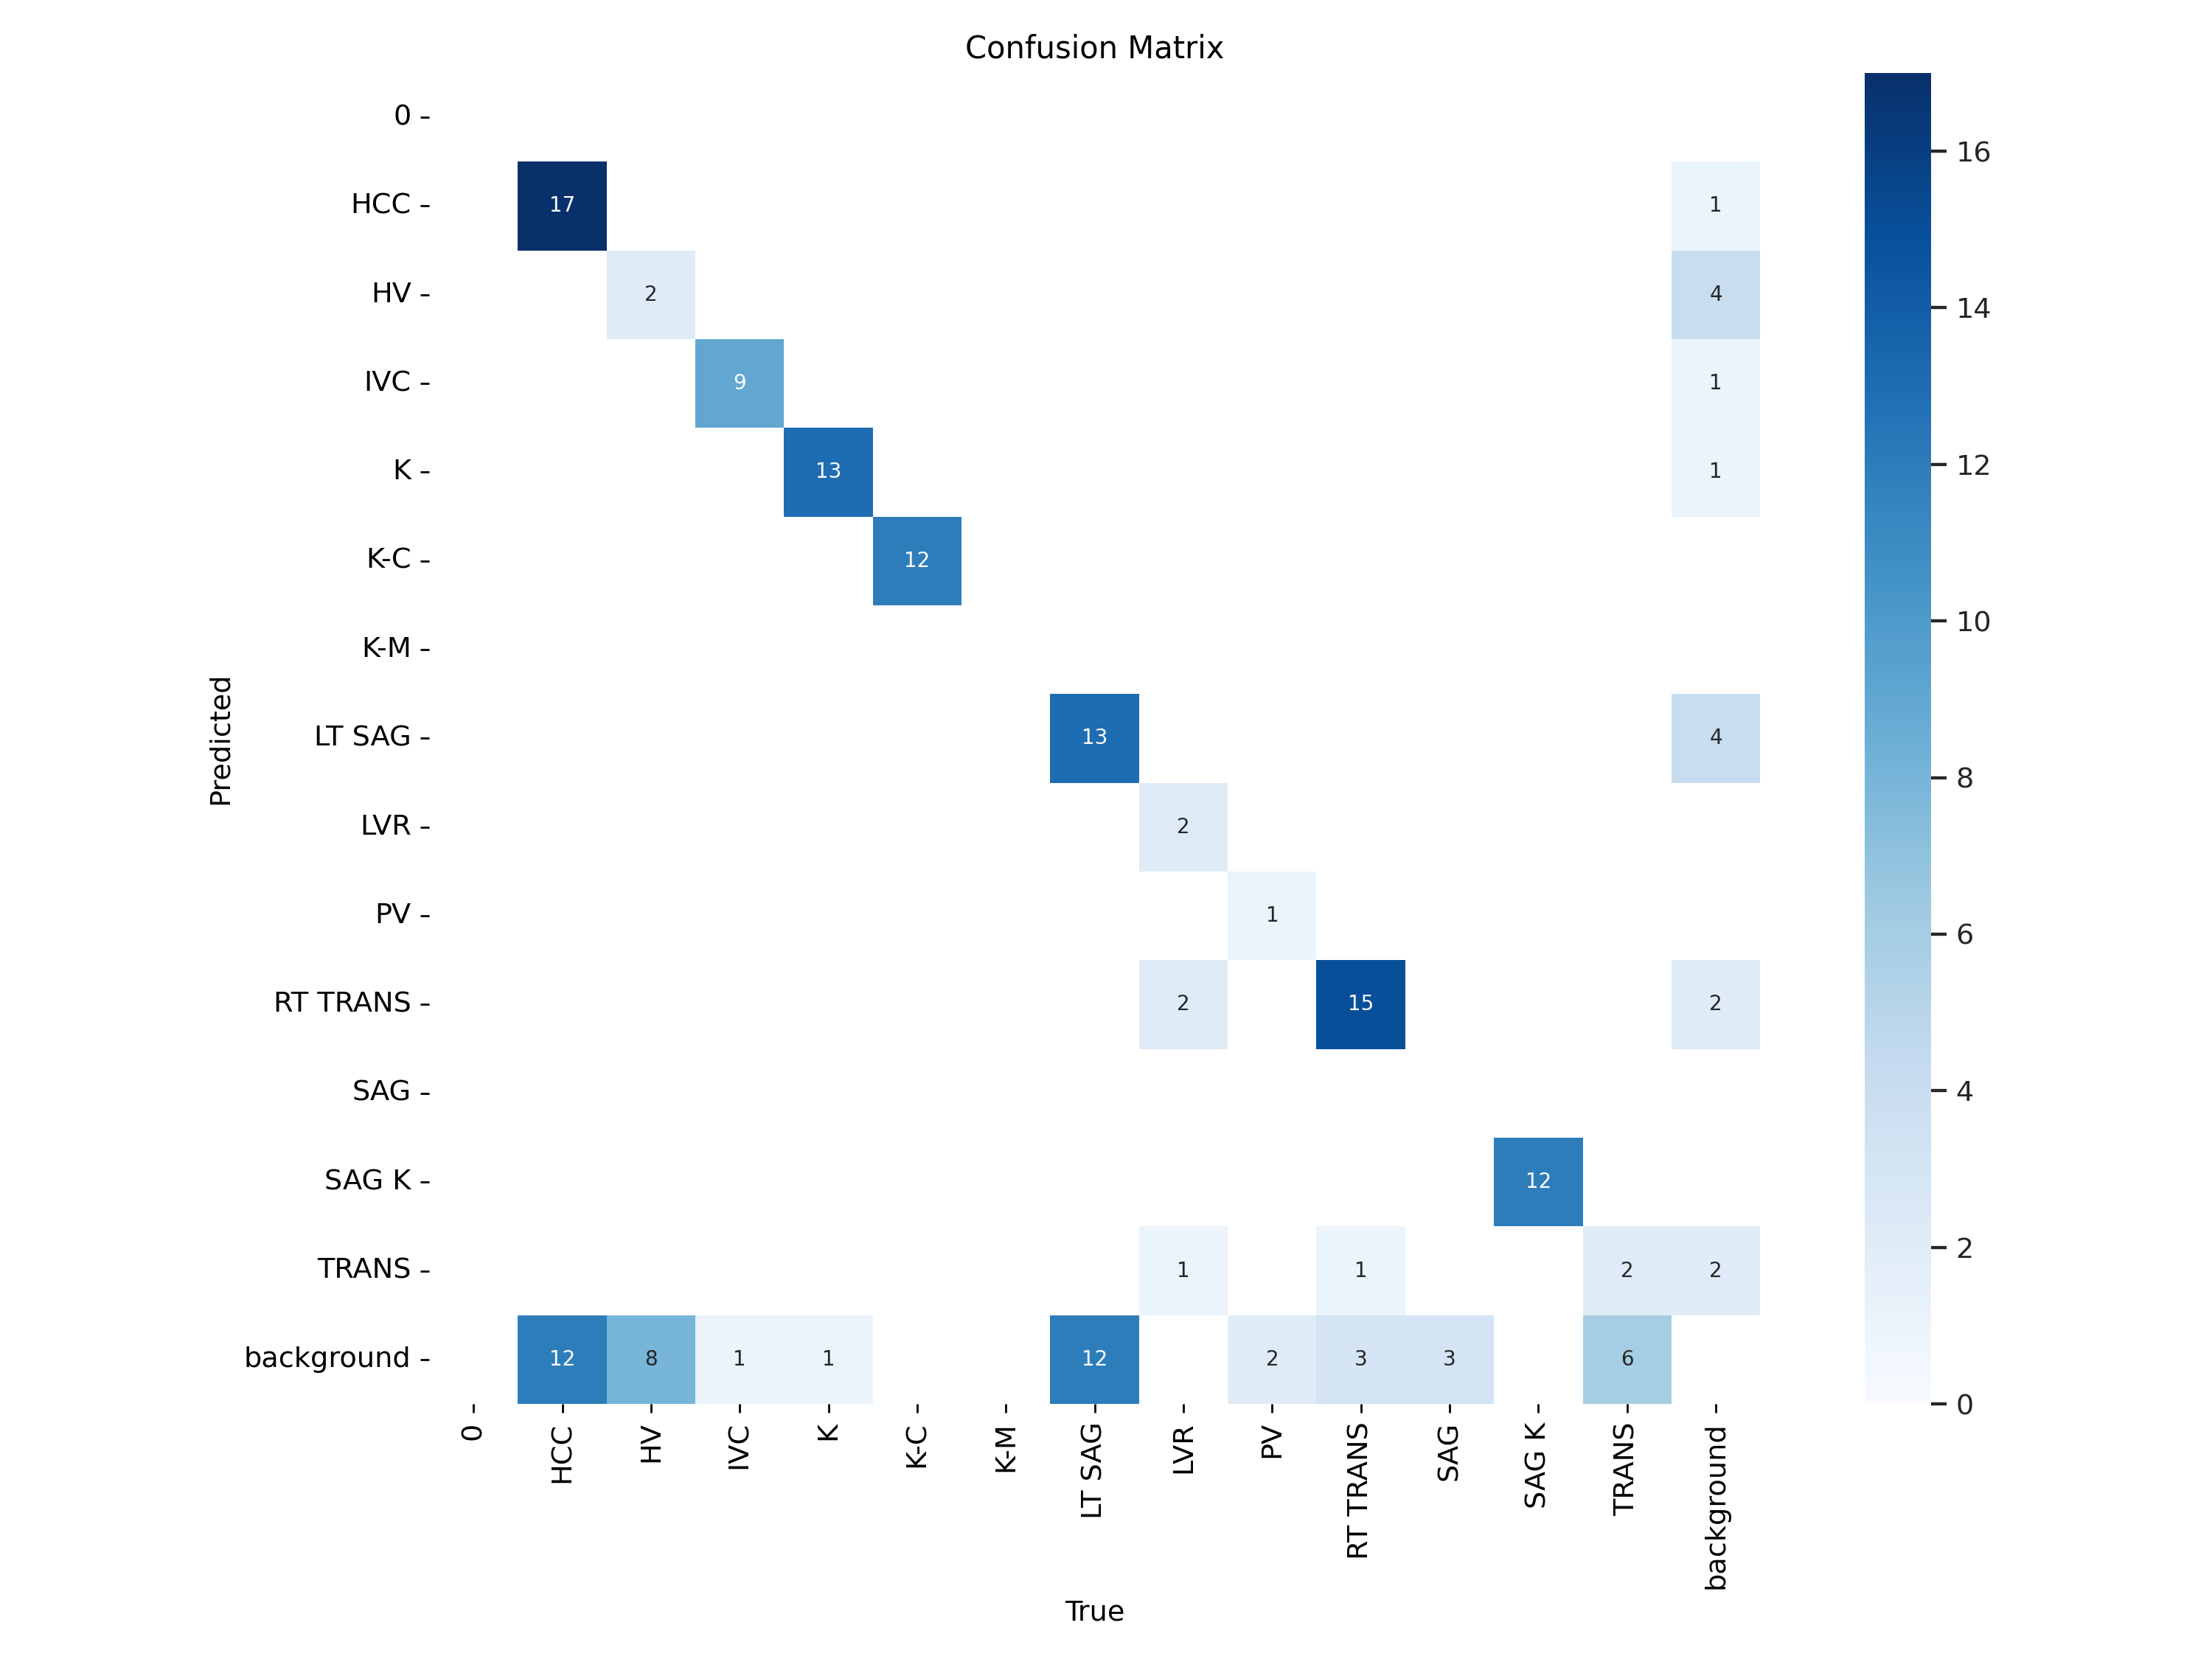

In [ ]:
%cd {HOME}
Image(filename=f'{HOME}/runs/detect/train/confusion_matrix.png', width=600)

/content


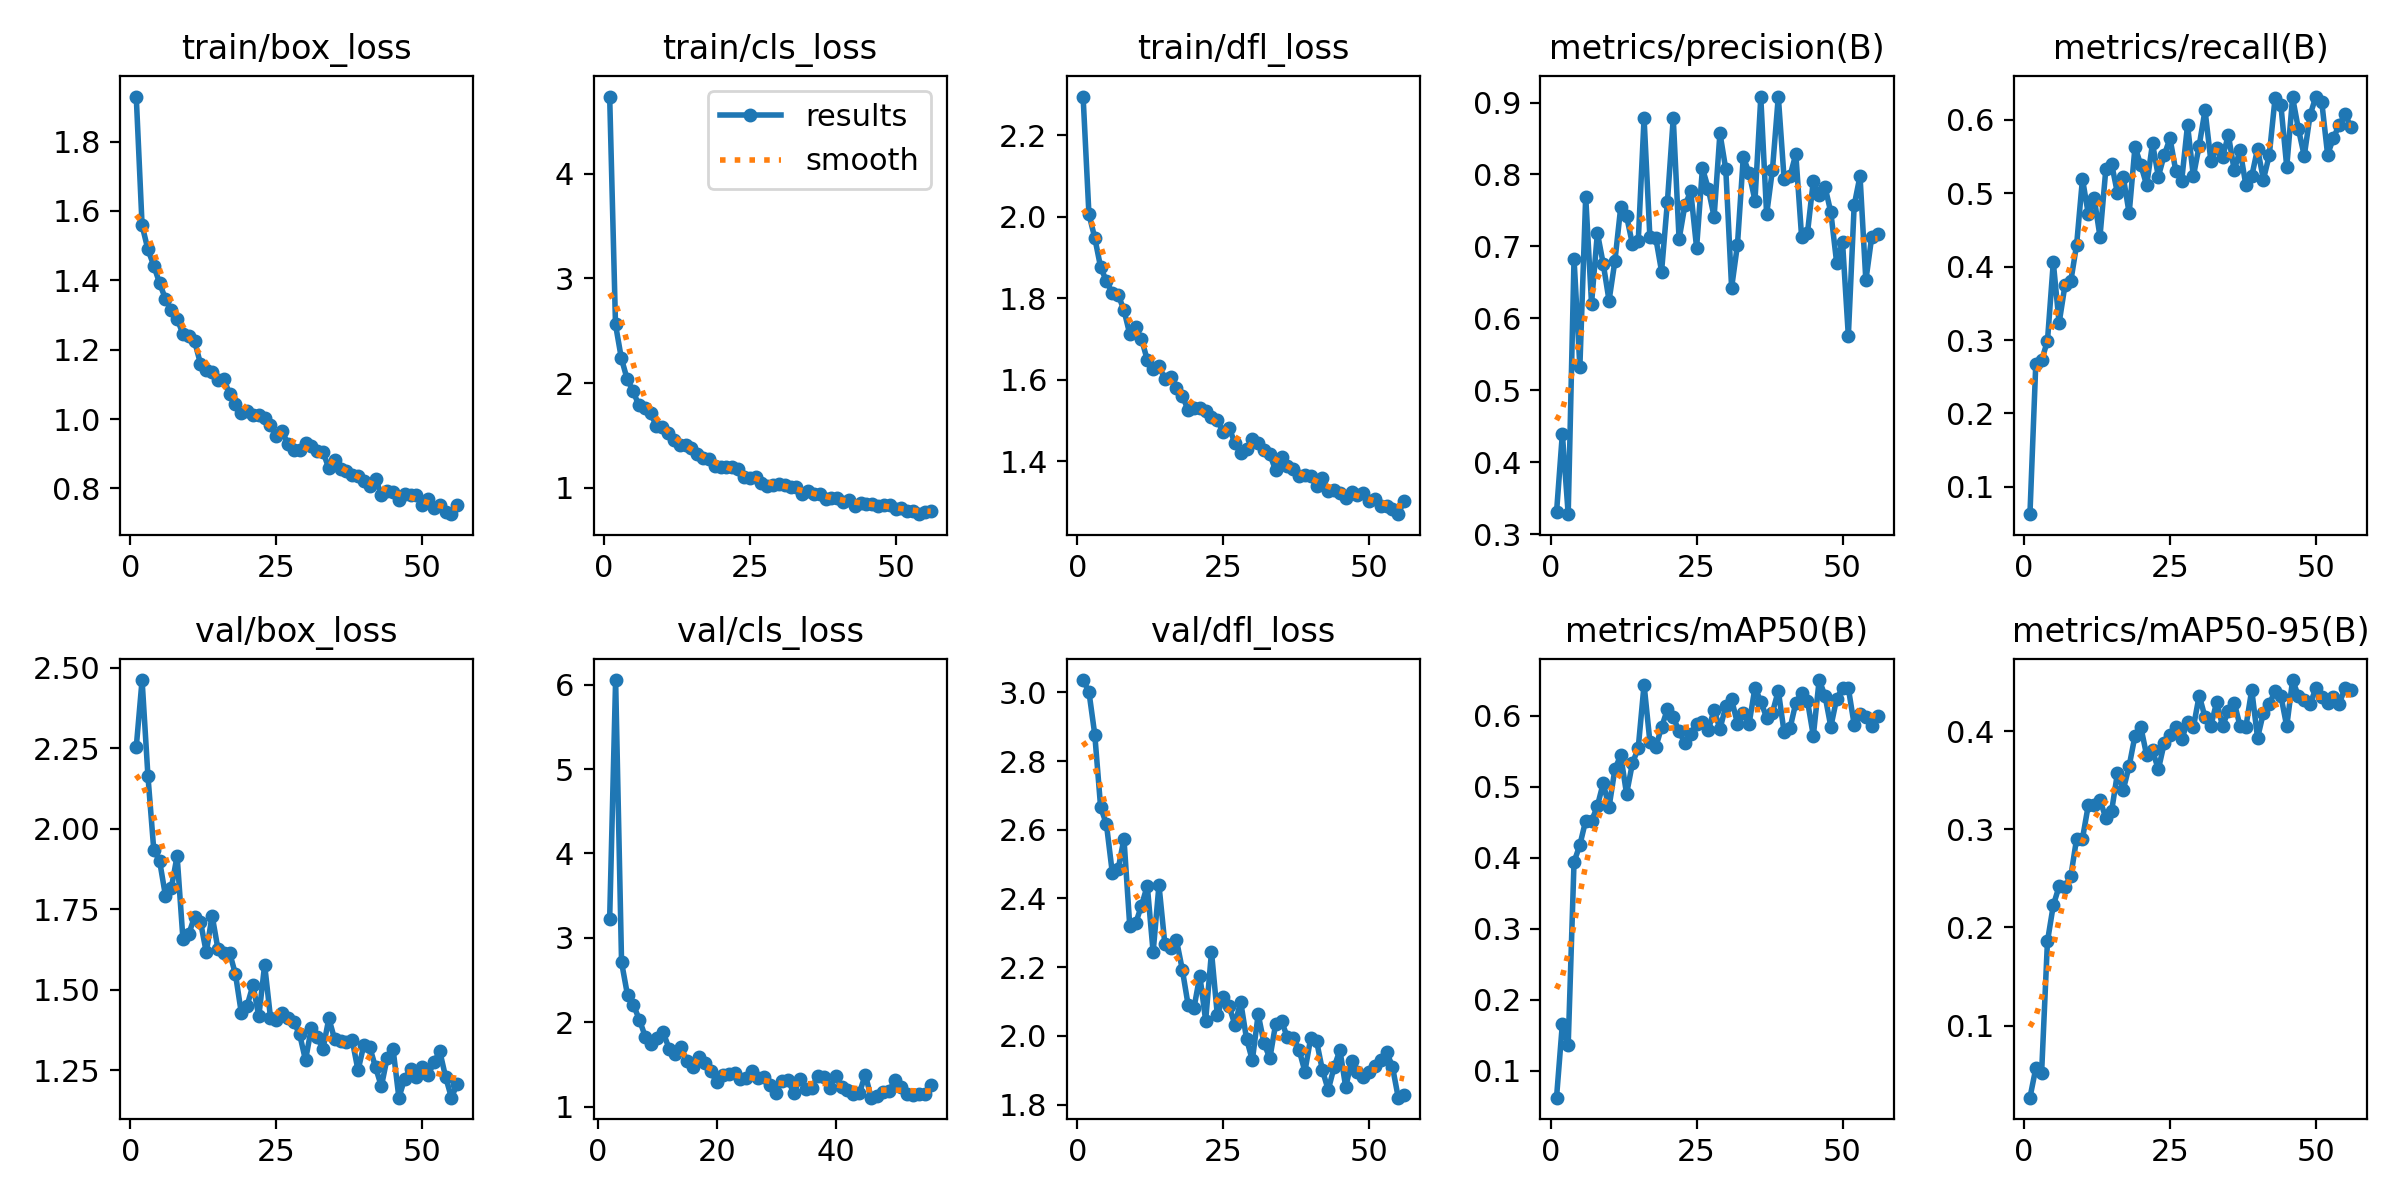

In [ ]:
%cd {HOME}
Image(filename=f'{HOME}/runs/detect/train/results.png', width=600)

/content


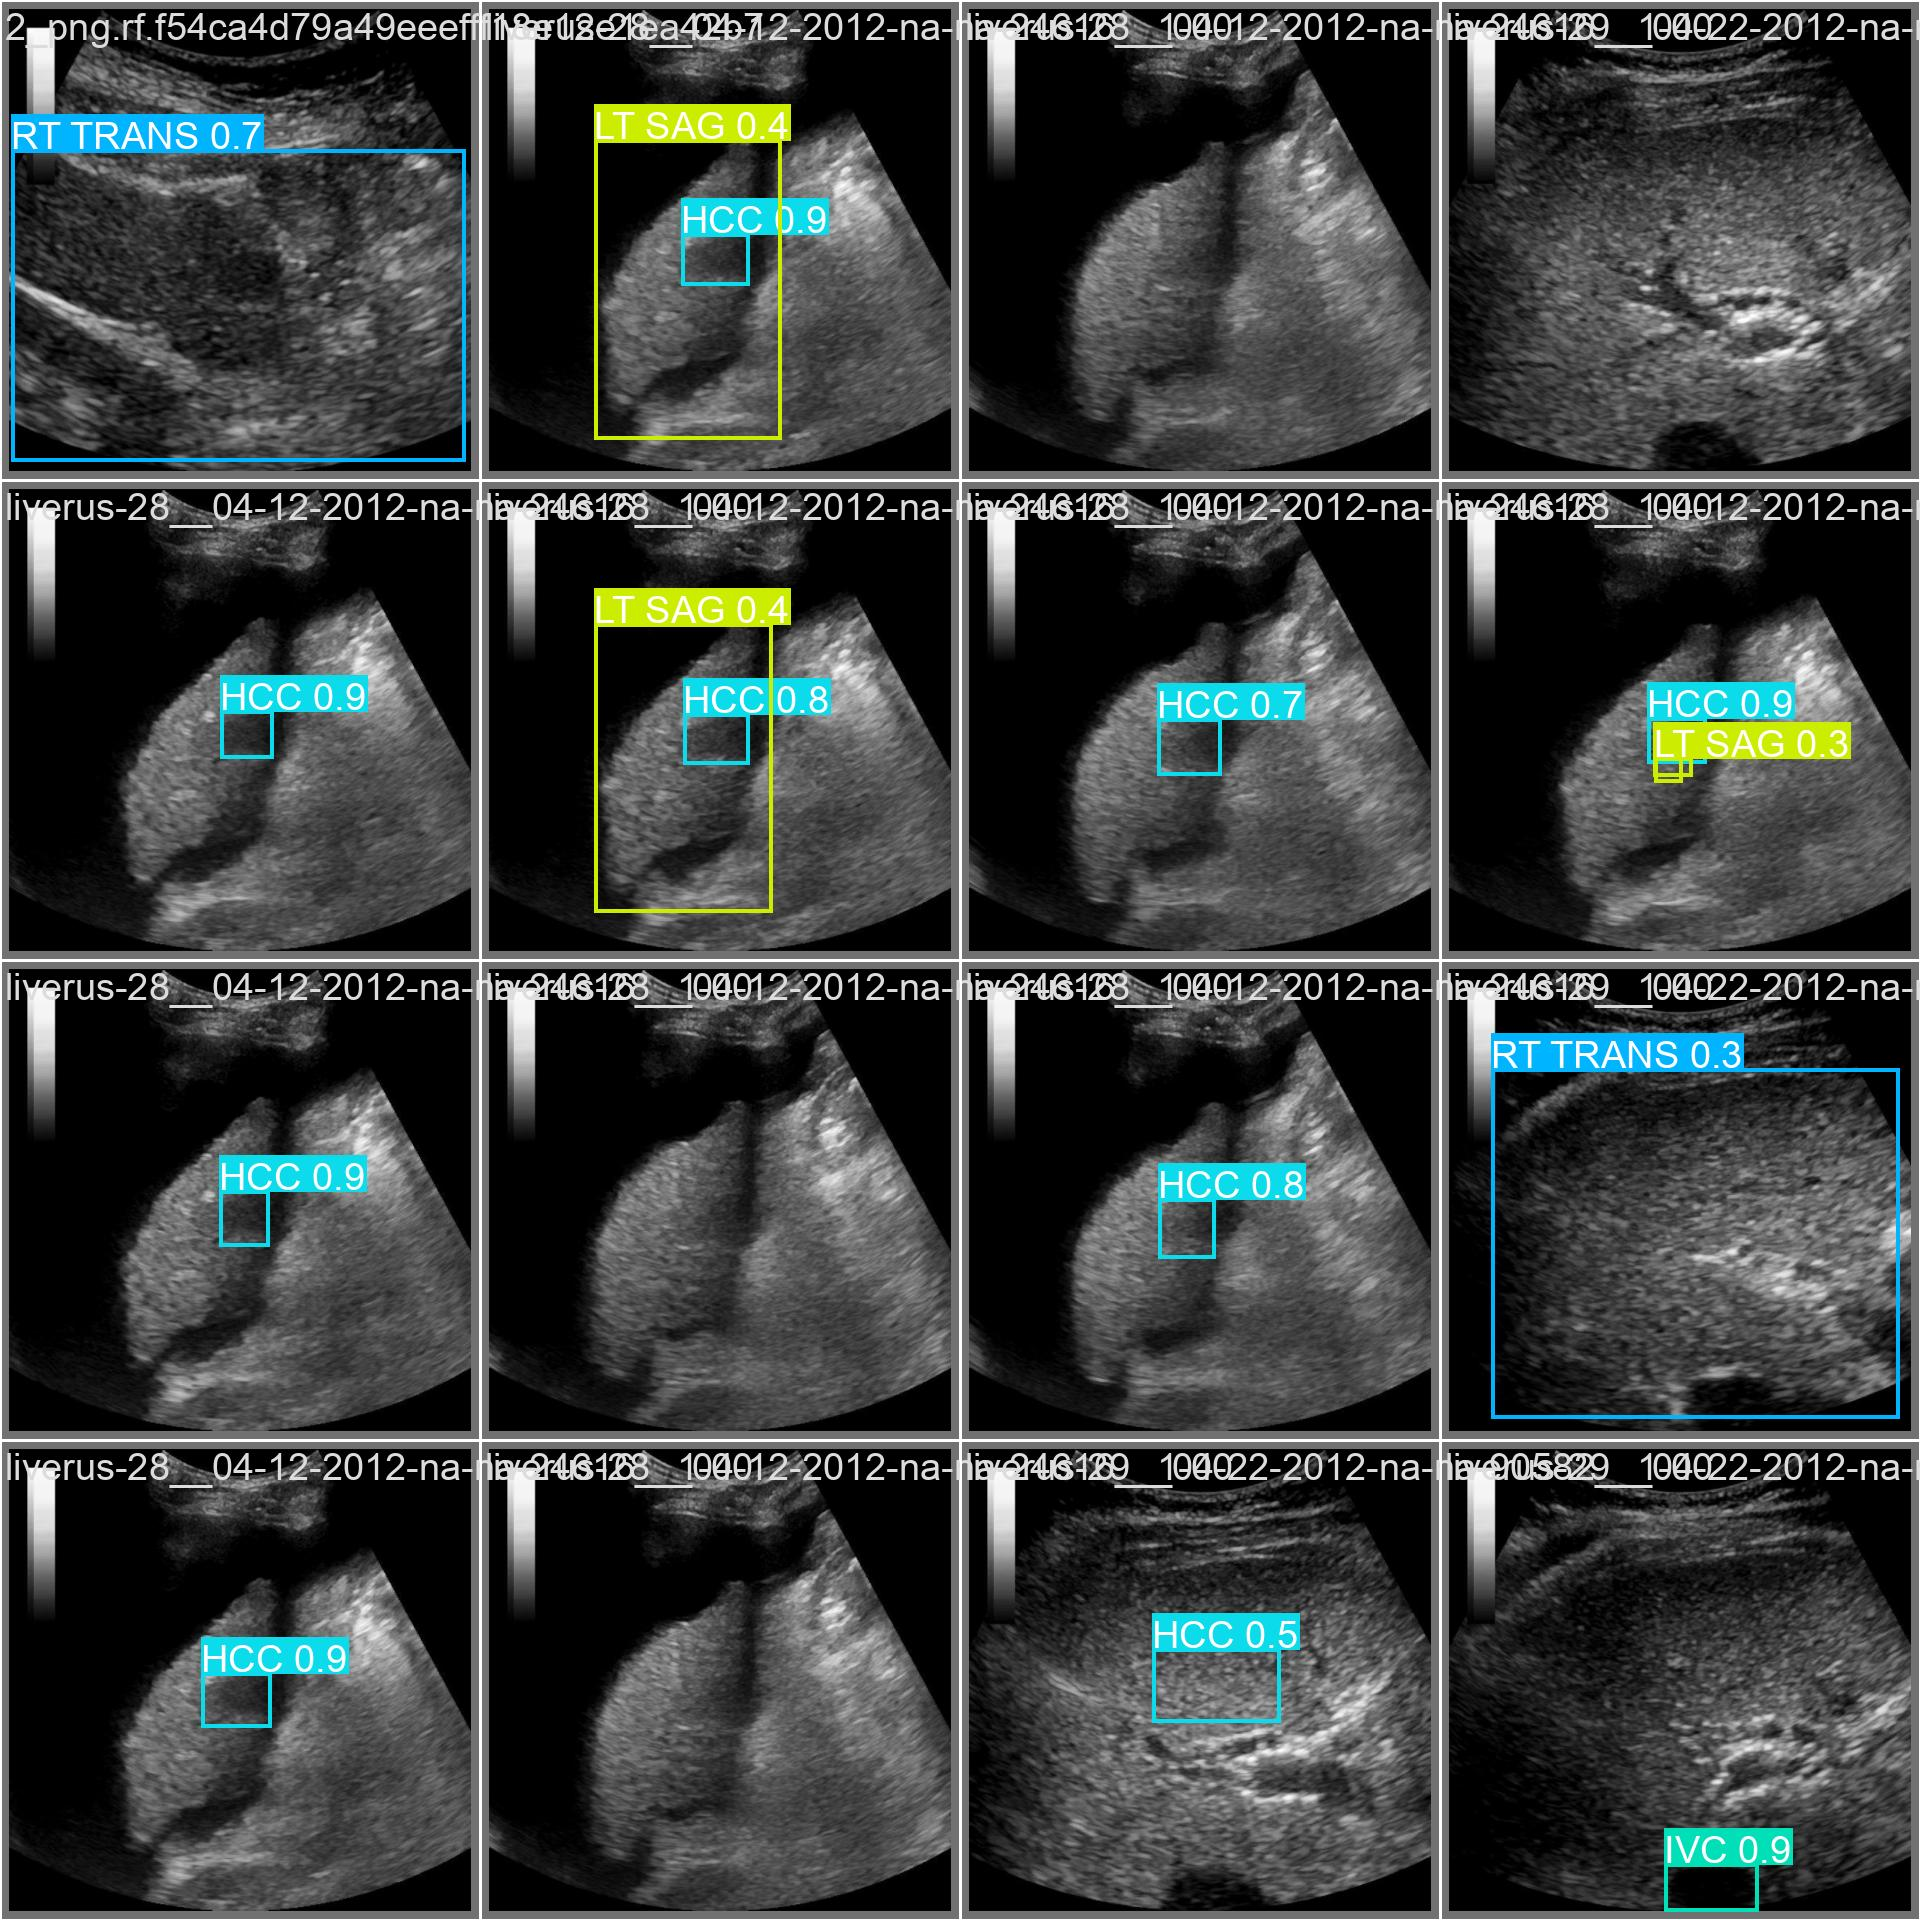

In [ ]:
%cd {HOME}
Image(filename=f'{HOME}/runs/detect/train/val_batch0_pred.jpg', width=600)

## Validate Custom Model

In [ ]:
%cd {HOME}

!yolo task=detect mode=val model={HOME}/runs/detect/train/weights/best.pt data={dataset.location}/data.yaml

/content
Ultralytics YOLOv8.2.103 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 168 layers, 11,131,002 parameters, 0 gradients, 28.5 GFLOPs
val: Scanning /content/datasets/liver_ultrasound-3/valid/labels.cache... 60 images, 0 backgrounds, 0 corrupt: 100% 60/60 [00:00<?, ?it/s]
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 139, len(boxes) = 150. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% 4/4 [00:02<00:00,  1.46it/s]
                   all         60        150      0.767      0.631       0.65      0.453
                   HCC         29         29      0.856      0.586      0.721      0.394
                    HV          5         10      0.286      0.282      0.257     0.0855
                   

## Inference with Custom Model

In [ ]:
%cd {HOME}
!yolo task=detect mode=predict model={HOME}/runs/detect/train/weights/best.pt conf=0.25 source={dataset.location}/test/images save=True

/content
Ultralytics YOLOv8.2.103 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 168 layers, 11,131,002 parameters, 0 gradients, 28.5 GFLOPs

image 1/60 /content/datasets/liver_ultrasound-3/test/images/39-2_png.rf.f47b81759b3f7e39003fed3cfb80566f.jpg: 800x800 1 K, 1 LVR, 22.9ms
image 2/60 /content/datasets/liver_ultrasound-3/test/images/39-6_png.rf.c4137463776232ff83c642236ffbb510.jpg: 800x800 1 K, 1 K-M, 1 LVR, 23.0ms
image 3/60 /content/datasets/liver_ultrasound-3/test/images/39-7_png.rf.d917440116790b12c240ea6daf854327.jpg: 800x800 1 K, 1 K-M, 1 LVR, 22.9ms
image 4/60 /content/datasets/liver_ultrasound-3/test/images/42_png.rf.ce7cb945048408d3c75886f51d3bbda8.jpg: 800x800 1 LVR, 22.9ms
image 5/60 /content/datasets/liver_ultrasound-3/test/images/4_png.rf.523d54ba07a6afd92213a54118303524.jpg: 800x800 (no detections), 22.9ms
image 6/60 /content/datasets/liver_ultrasound-3/test/images/5-2_png.rf.a911cf28c09c0d566e66f4189e0e1df9.jpg: 800x800 1 K, 1 L

**NOTE:** Let's take a look at few results.

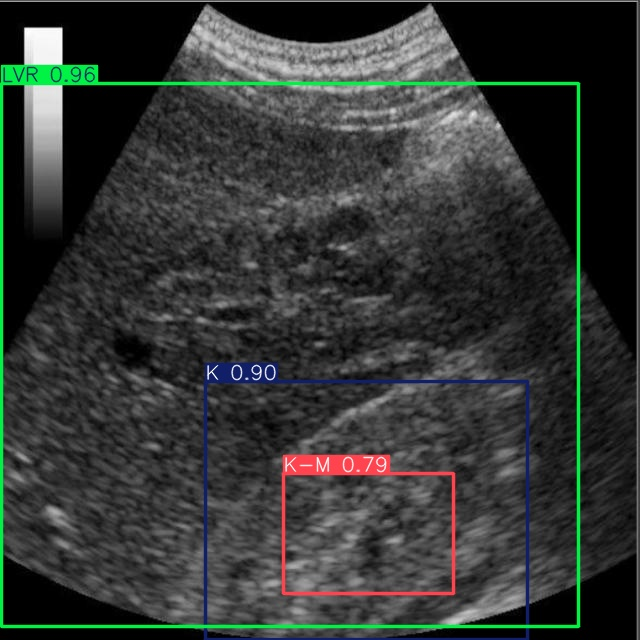

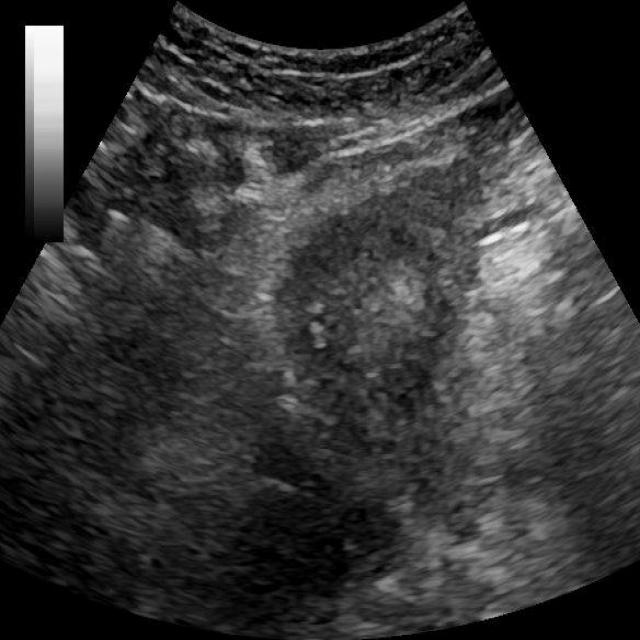

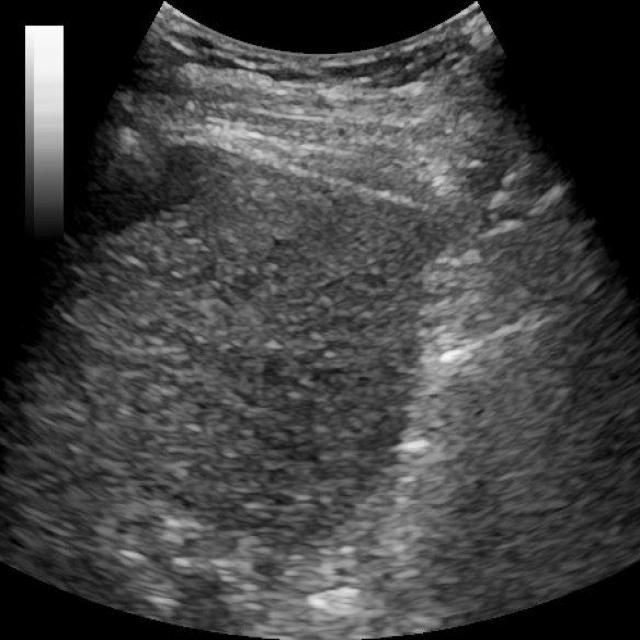

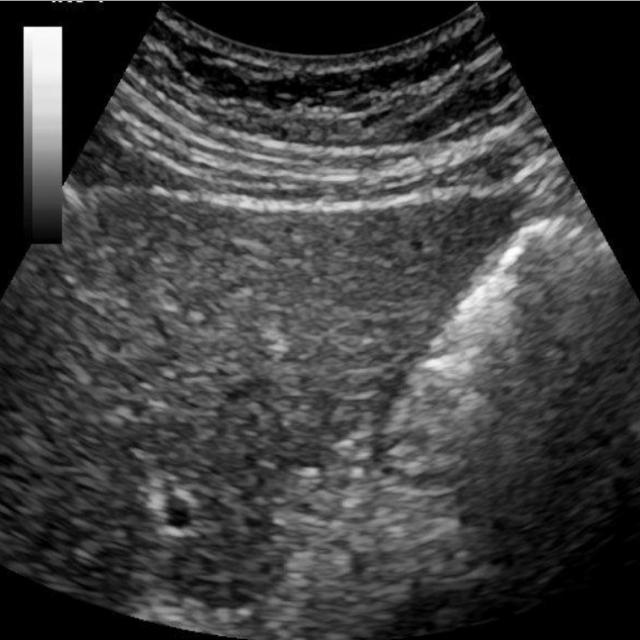

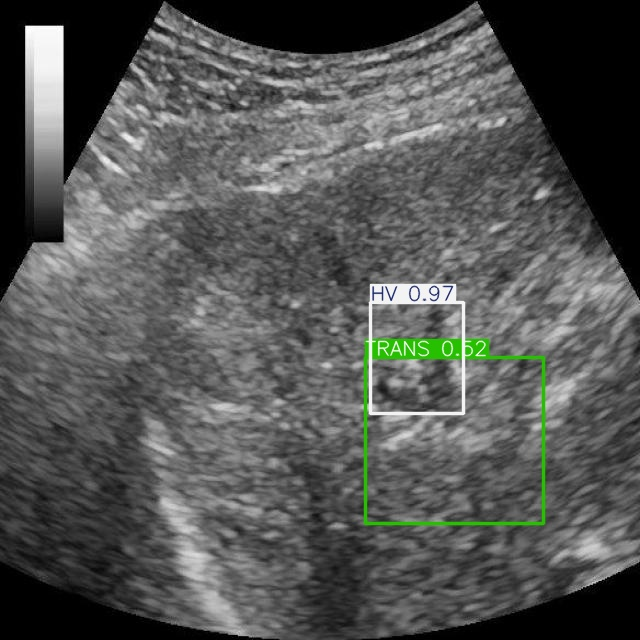

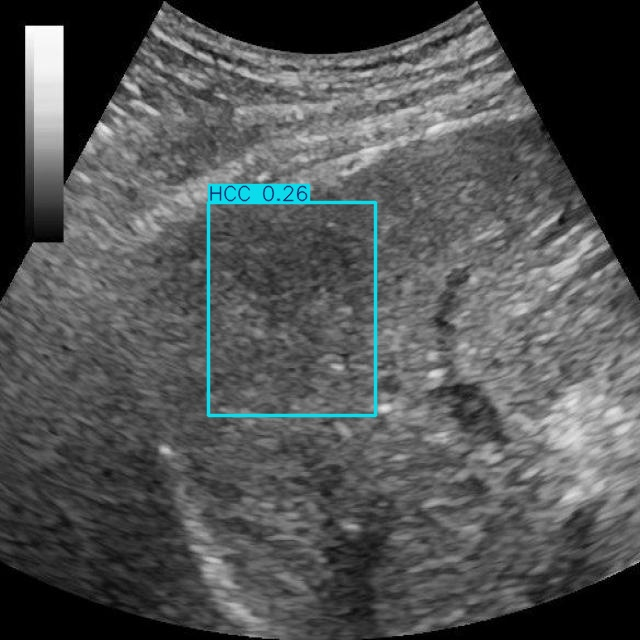

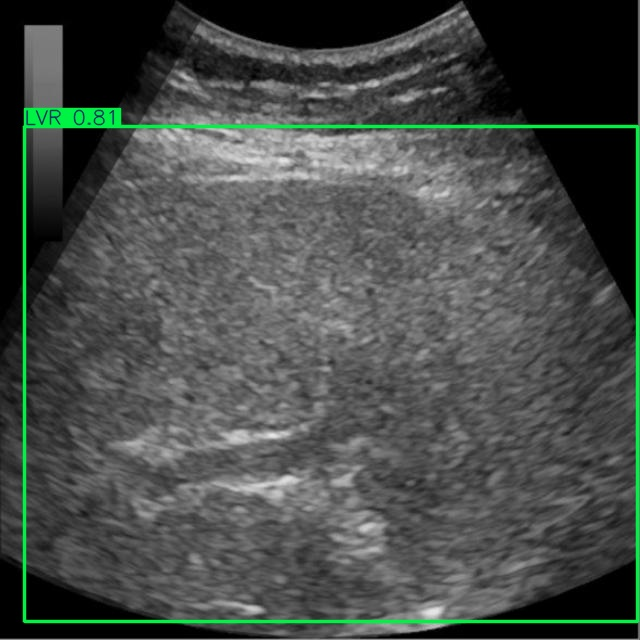

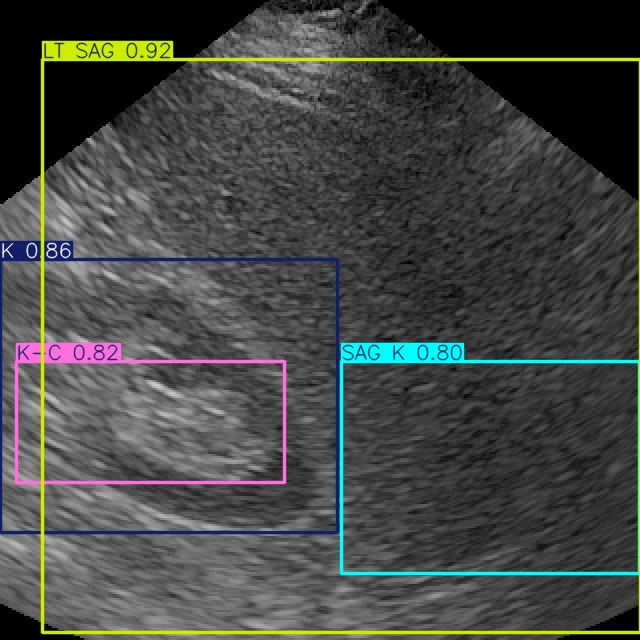

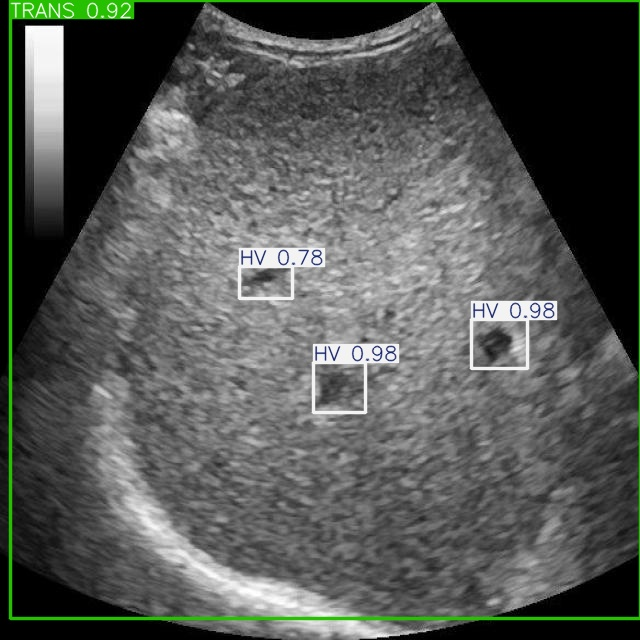

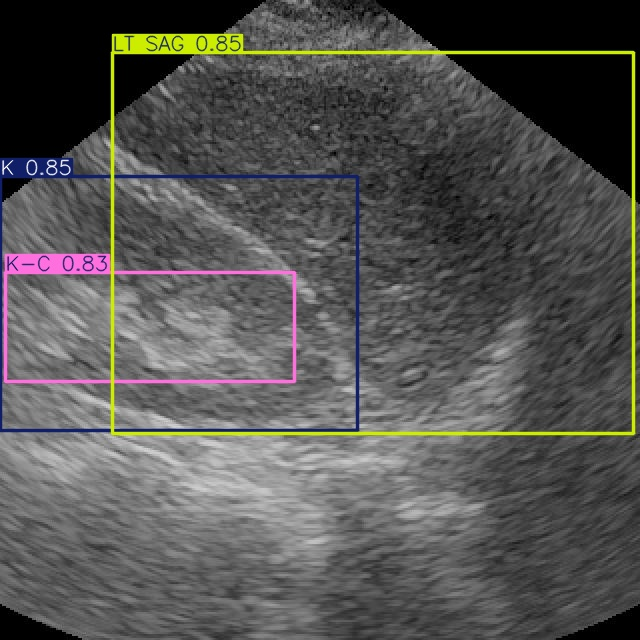

In [ ]:
import glob
from IPython.display import Image, display

base_path = '/content/runs/detect/'

subfolders = [os.path.join(base_path, d) for d in os.listdir(base_path)
              if os.path.isdir(os.path.join(base_path, d)) and d.startswith('predict')]

latest_folder = max(subfolders, key=os.path.getmtime)

image_paths = glob.glob(f'{latest_folder}/*.jpg')[:10]

for image_path in image_paths:
    display(Image(filename=image_path, width=600))
    print("\n")

In [ ]:
from google.colab import files
files.download('runs/detect/train/weights/best.pt')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:

project.version(dataset.version).deploy(model_type="yolov8", model_path=f"{HOME}/runs/detect/train/")

View the status of your deployment at: https://app.roboflow.com/hccai/liver_ultrasound-phwos/3
Share your model with the world at: https://universe.roboflow.com/hccai/liver_ultrasound-phwos/model/3
